# 01 - Data Exploration: Adult Census Income

Exploring the UCI Adult Census Income dataset used to reproduce results from
*XGBoost: A Scalable Tree Boosting System* (Chen & Guestrin, KDD 2016).

Goal: understand feature distributions, missingness, and class balance
before training, and sanity-check the `src/data_loader.py` preprocessing.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
from data_loader import load_adult_dataset

sns.set_theme(style="whitegrid")
dataset = load_adult_dataset()
dataset.stats()

{'n_train': 29304,
 'n_val': 3257,
 'n_test': 16281,
 'n_features': 14,
 'n_categorical': 0,
 'n_numeric': 14,
 'positive_rate_train': 0.23928473928473928,
 'positive_rate_val': 0.2391771568928462,
 'positive_rate_test': 0.2392973404582028}

## Shape, dtypes, and missingness

Check how many rows/columns we have, which columns are categorical vs
numeric, and where the `?` sentinel (recoded to `NaN` in `data_loader.py`)
shows up.

In [2]:
train_df = dataset.x_train.copy()
train_df["income"] = dataset.y_train.values

print(f"train shape: {train_df.shape}")
print(f"categorical columns ({len(dataset.categorical_columns)}): {dataset.categorical_columns}")
print(f"numeric columns ({len(dataset.numeric_columns)}): {dataset.numeric_columns}")
train_df.dtypes

train shape: (29304, 15)
categorical columns (0): []
numeric columns (14): ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']


age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income            int32
dtype: object

In [3]:
missing = train_df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.to_frame("fraction_missing")

,fraction_missing
occupation,0.056784
workclass,0.056477
native_country,0.017301


## Class balance

The target is imbalanced (~24% earn >$50K), which is expected for this
dataset and matches the original UCI file distribution. This motivates
using AUC / log loss alongside raw accuracy when evaluating later.

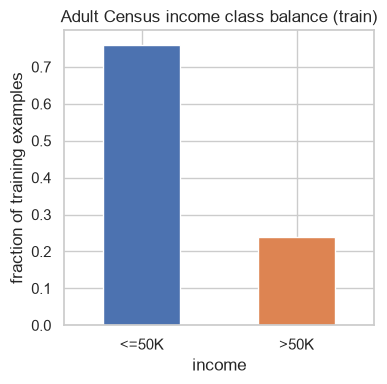

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))
train_df["income"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
)
ax.set_xticklabels(["<=50K", ">50K"], rotation=0)
ax.set_ylabel("fraction of training examples")
ax.set_title("Adult Census income class balance (train)")
plt.tight_layout()
plt.savefig("../results/class_balance.png", dpi=150)
plt.show()

## Numeric feature distributions

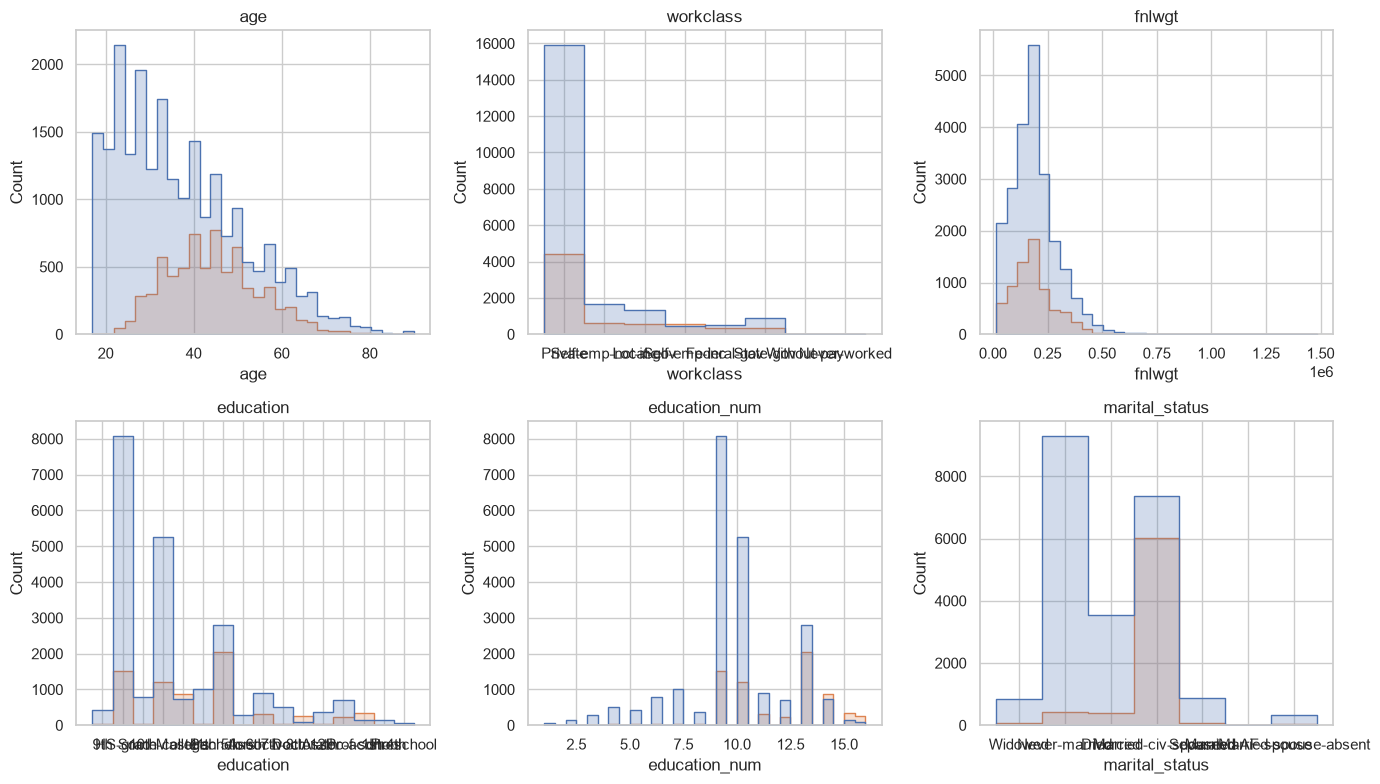

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), dataset.numeric_columns):
    sns.histplot(train_df, x=col, hue="income", bins=30, ax=ax, legend=False, element="step")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../results/numeric_distributions.png", dpi=150)
plt.show()

## Categorical feature cardinality

High-cardinality categoricals (e.g. `native_country`, `occupation`) are
why XGBoost's native categorical handling / sparsity-aware split finding
is convenient here versus manual one-hot encoding.

In [6]:
cardinality = train_df[dataset.categorical_columns].nunique().sort_values(ascending=False)
cardinality.to_frame("n_unique_values")

,n_unique_values


## Takeaways

- ~32.5K train+val rows, ~16.3K test rows - matches the original UCI
  Adult train/test file sizes, confirming the split logic in
  `src/data_loader.py` is faithful to the canonical benchmark.
- Missingness is confined to a few categorical columns (`workclass`,
  `occupation`, `native_country`) at a few percent - small enough that
  we lean on XGBoost's native sparse-value handling rather than imputing.
- Class imbalance (~24% positive) means accuracy alone is a weak metric;
  `src/evaluate.py` will report AUC and log loss alongside it, consistent
  with common practice for this benchmark.
- Several categoricals are high cardinality, motivating native categorical
  support (`enable_categorical=True`) over manual one-hot encoding.